# Change-Target Modeling Track

This notebook tests a second-stage modeling direction for the CAST+ conflict forecasting project: predicting **month-to-month change in conflict intensity** instead of only predicting raw event counts.

The original project forecasts monthly conflict event counts at the admin-1 level. This notebook keeps that project structure, but redesigns the target so the model focuses on escalation and de-escalation dynamics.

## Main Question

Can we improve conflict forecasting by predicting change?

Instead of modeling the raw count directly:

`y_t`

this notebook models:

`delta_y = y_t - y_(t-1)`

A positive delta means conflict increased from the previous month.  
A negative delta means conflict decreased from the previous month.  
A zero delta means the conflict count stayed the same.

## Targets

The notebook creates signed change targets for:

- Battles
- Explosions/Remote violence
- Violence against civilians

These are represented as:

- `delta_battles`
- `delta_remote_violence`
- `delta_vac`

## Modeling Setup

Because delta targets can be negative, count-based objectives such as Poisson are not appropriate here.

This notebook compares models that can handle signed regression targets:

- RandomForestRegressor
- LightGBM with standard regression objective
- CatBoostRegressor
- HistGradientBoostingRegressor

The main baseline comparison is against RandomForest, since RandomForest is the original basic model.

## Feature Logic

The feature set keeps the useful conflict, neighbor, time, religion, World Bank, risk, and engineered features from the processed dataset.(lagged holiday features are excluded)

This is because holidays are calendar-known features, not historical signals like conflict lags.

## Evaluation

The notebook uses the same basic chronological split logic as the original project:

- last 6 months as test period
- earlier months as training period
- results separated by target

Evaluation uses:
- MAE
- RMSE
- model win counts by region and target
- feature importance (temporary test)
- prediction bias

In [4]:
from pathlib import Path
import sys
import warnings
import os
from joblib import parallel_backend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

REPO_ROOT = Path(r'C:\Users\Rosa Daneshmandnia\predicting-global-conflict')
if str(REPO_ROOT / 'forecast_model') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'forecast_model'))

RANDOM_STATE = 42

In [5]:
model_data = pd.read_csv(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv")

model_data = model_data.set_index(['matched_admin1_id', 'month_year'])

model_data = model_data.sort_index()

print(f'Loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols')
model_data.info()
model_data.describe()

Loaded: 278,820 rows x 100 cols
<class 'pandas.DataFrame'>
MultiIndex: 278820 entries, ('ABW - Aruba', '2018-01') to (nan, '2025-06')
Data columns (total 100 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Battles (t-1)                                275633 non-null  float64
 1   Explosions/Remote violence (t-1)             275633 non-null  float64
 2   Protests (t-1)                               275633 non-null  float64
 3   Riots (t-1)                                  275633 non-null  float64
 4   Strategic developments (t-1)                 275633 non-null  float64
 5   Violence against civilians (t-1)             275633 non-null  float64
 6   Excessive force against protesters (t-1)     275633 non-null  float64
 7   Agreement (t-1)                              275633 non-null  float64
 8   Explosions/Remote violence_neighbours (t-1)  275633 non-null  float64
 9   St

,Battles (t-1),Explosions/Remote violence (t-1),Protests (t-1),Riots (t-1),Strategic developments (t-1),Violence against civilians (t-1),Excessive force against protesters (t-1),Agreement (t-1),Explosions/Remote violence_neighbours (t-1),Strategic developments_neighbours (t-1),...,risk_military_coup,risk_natural_disaster,risk_political_assassination,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1)
count,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,...,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000
mean,1.238741,1.409740,3.471569,0.481844,0.565821,0.856490,0.013707,0.009556,6.946316,2.895836,...,0.069260,0.350133,0.105297,0.099577,0.380432,0.247174,0.138634,0.068273,0.342364,0.099778
std,13.849694,23.869244,13.955840,5.851017,3.813787,4.079164,0.431490,0.165491,72.337224,12.018981,...,0.333235,1.146762,0.844635,0.489615,1.042766,0.675020,0.531955,0.331815,1.130166,0.831644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1664.000000,1773.000000,715.000000,862.000000,286.000000,234.000000,119.000000,29.000000,3961.000000,464.000000,...,16.000000,37.000000,26.000000,12.000000,19.000000,31.000000,23.000000,16.000000,37.000000,26.000000


In [17]:
RAW_TARGETS = [
    'Battles',
    'Explosions/Remote violence',
    'Violence against civilians',
]

DELTA_TARGET_MAP = {
    'Battles': 'delta_battles',
    'Explosions/Remote violence': 'delta_remote_violence',
    'Violence against civilians': 'delta_vac',
}

DELTA_TARGETS = []

for target in RAW_TARGETS:
    lag_col = f'{target} (t-1)'
    delta_col = DELTA_TARGET_MAP[target]

    if lag_col in model_data.columns:
        model_data[delta_col] = model_data[target] - model_data[lag_col]
        DELTA_TARGETS.append(delta_col)

delta_summary = model_data[DELTA_TARGETS].agg(['mean', 'std', 'min', 'max']).T.round(3)
delta_summary['zero_share'] = (model_data[DELTA_TARGETS] == 0).mean().round(3)
delta_summary['negative_share'] = (model_data[DELTA_TARGETS] < 0).mean().round(3)
delta_summary['positive_share'] = (model_data[DELTA_TARGETS] > 0).mean().round(3)

delta_summary

,mean,std,min,max,zero_share,negative_share,positive_share
delta_battles,-0.006,4.142,-582.0,385.0,0.857,0.066,0.065
delta_remote_violence,0.004,7.362,-1004.0,879.0,0.922,0.033,0.033
delta_vac,-0.001,1.988,-149.0,188.0,0.799,0.095,0.094


In [8]:
#same as raw notebook
all_cols = model_data.columns.tolist()

conflict_lag_features = [c for c in all_cols if c.endswith('(t-1)') and c.split(' (t-1)')[0] in [
    'Battles', 'Explosions/Remote violence', 'Protests', 'Riots',
    'Strategic developments', 'Violence against civilians',
    'Excessive force against protesters', 'Agreement'
]]

neighbor_features = [c for c in all_cols if '_neighbours (t-1)' in c]

time_features = [
    c for c in all_cols
    if c == 'linear_month_trend' or c == 'year' or c.startswith('month_') or c.startswith('quarter_')
]

worldbank_lag_features = [c for c in [
    'inflation (t-1)', 'youth_unemployment (t-1)', 'income_inequality (t-1)', 'income_level_code (t-1)'
] if c in all_cols]

religion_features = [c for c in [
    'majority_religion', 'majority_pct', 'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct', 'nonreligpct'
] if c in all_cols]

holiday_current_features = [c for c in all_cols if 'holiday_count' in c and '(t-1)' not in c]

holiday_interaction_current = [c for c in [
    'weighted_holidays_majority', 'weighted_holidays_minority1', 'weighted_holidays_minority2',
    'minority_tension_minority1', 'minority_tension_minority2', 'minority_tension_total',
    'total_religious_mobilization'
] if c in all_cols]

wbd_engineered_features = [c for c in [
    'structural_vulnerability', 'inflation_shock', 'shock_vulnerability', 'capacity_adjusted_risk',
    'inflation_change', 'high_inequality_flag', 'inflation_shock_poor',
    'conflict_momentum', 'violence_escalation', 'macro_conflict_pressure'
] if c in all_cols]

risk_features = [c for c in all_cols if c.startswith('risk_')]

excluded_holiday_lags = [c for c in all_cols if 'holiday_count' in c and '(t-1)' in c]

excluded_holiday_interaction_lags = [
    c for c in all_cols
    if '(t-1)' in c and any(k in c for k in ['weighted_holidays', 'minority_tension', 'mobilization'])
]

baseline_feature_cols = list(dict.fromkeys(
    conflict_lag_features
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_features
))

len(baseline_feature_cols)

80

In [13]:
def split_region_data(region_data, test_horizon=6):
    train = region_data.iloc[:-test_horizon]
    test = region_data.iloc[-test_horizon:]
    return train, test


def encode_categoricals(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()

        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

        X_train[col] = le.fit_transform(X_train[col])

        known = set(le.classes_)
        X_test[col] = X_test[col].map(
            lambda x: le.transform([x])[0] if x in known else -1
        )

    return X_train, X_test


def prepare_rf_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    num_bool_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    X_train[num_bool_cols] = X_train[num_bool_cols].fillna(0)
    X_test[num_bool_cols] = X_test[num_bool_cols].fillna(0)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def prepare_catboost_native_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

    return X_train, X_test, cat_cols


def prepare_catboost_encoded_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


CATBOOST_MODE = "native"  # or "encoded"


def prepare_catboost_inputs(train_df, test_df, feature_cols, mode=CATBOOST_MODE):
    if mode == "native":
        return prepare_catboost_native_inputs(train_df, test_df, feature_cols)
    elif mode == "encoded":
        X_train, X_test = prepare_catboost_encoded_inputs(train_df, test_df, feature_cols)
        return X_train, X_test, None
    else:
        raise ValueError("mode must be 'native' or 'encoded'")


def prepare_lgbm_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [14]:
MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'LightGBM_Regression': LGBMRegressor(
        objective='regression',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
    ),
}

MODELS

{'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=1, random_state=42),
 'LightGBM_Regression': LGBMRegressor(learning_rate=0.05, max_depth=4, n_estimators=500,
               objective='regression', random_state=42, verbose=-1),
 'CatBoost': CatBoostRegressor(depth=4, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0),
 'HistGradientBoosting': HistGradientBoostingRegressor(learning_rate=0.05, max_depth=4, max_iter=500,
                               random_state=42)}

In [15]:
all_regions = model_data.index.get_level_values('matched_admin1_id').unique()

VALID_REGIONS = []
skipped_too_short = []
skipped_all_zero = []

for region in all_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        skipped_too_short.append(region)
        continue

    train_data, test_data = split_region_data(region_data)

    if train_data[DELTA_TARGETS].nunique().max() <= 1:
        skipped_all_zero.append(region)
        continue

    VALID_REGIONS.append(region)

print(f"Valid regions: {len(VALID_REGIONS)}")
print(f"Skipped (<12 months): {len(skipped_too_short)}")
print(f"Skipped (no variation in delta targets): {len(skipped_all_zero)}")

VALID_REGIONS[:10]

Valid regions: 2205
Skipped (<12 months): 0
Skipped (no variation in delta targets): 893


['AFG - Badakhshan',
 'AFG - Badghis',
 'AFG - Baghlan',
 'AFG - Balkh',
 'AFG - Bamyan',
 'AFG - Daykundi',
 'AFG - Farah',
 'AFG - Faryab',
 'AFG - Ghazni',
 'AFG - Ghor']

In [10]:
RUN_REGIONS = VALID_REGIONS
RUN_TARGETS = DELTA_TARGETS

results = []
feature_importances = {}

with parallel_backend("sequential"):
    for region in RUN_REGIONS:
        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None
    
        for target in RUN_TARGETS:
            train_pair = train_data[baseline_feature_cols + [target]].copy()
            test_pair = test_data[baseline_feature_cols + [target]].copy()
    
            train_pair = train_pair[train_pair[target].notna()]
            test_pair = test_pair[test_pair[target].notna()]
    
            if len(train_pair) == 0 or len(test_pair) == 0:
                continue
    
            y_train = train_pair[target]
            y_test = test_pair[target]
    
            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]
    
            X_train_rf, X_test_rf = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_lgbm, X_test_lgbm = prepare_lgbm_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_hgb, X_test_hgb = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
                train_pair, test_pair, baseline_feature_cols
            )
    

            for model_name, model in MODELS.items():
                try:
                    if model_name == 'RandomForest':
                        X_tr, X_te = X_train_rf, X_test_rf
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    elif model_name == 'LightGBM_Regression':
                        X_tr, X_te = X_train_lgbm, X_test_lgbm
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values

                    elif model_name == 'HistGradientBoosting':
                        X_tr, X_te = X_train_hgb, X_test_hgb
                        fit_kwargs = {}
    
                    else:
                        X_tr, X_te = X_train_cb, X_test_cb
                        fit_kwargs = {}
                        if cat_cols_cb is not None:
                            fit_kwargs['cat_features'] = cat_cols_cb
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    model.fit(X_tr, y_train, **fit_kwargs)
                    y_pred = model.predict(X_te)
    
                    results.append({
                        'region': region,
                        'target': target,
                        'model': model_name,
                        'mae': mean_absolute_error(y_test, y_pred),
                        'rmse': rmse(y_test, y_pred),
                        'mean_actual': y_test.mean(),
                        'mean_pred': float(np.mean(y_pred)),
                    })
    
                    if hasattr(model, 'feature_importances_'):
                        feature_importances[(model_name, region, target)] = pd.Series(
                            model.feature_importances_,
                            index=baseline_feature_cols,
                        )
    
                except Exception as exc:
                    print(f'ERROR | {model_name} | {region} | {target}: {exc}')

results_df = pd.DataFrame(results)
print(f"Rows collected: {len(results_df)}")
results_df

Rows collected: 17356


,region,target,model,mae,rmse,mean_actual,mean_pred
0,AFG - Badakhshan,delta_battles,RandomForest,0.860000,1.062670,0.333333,0.413333
1,AFG - Badakhshan,delta_battles,LightGBM_Regression,1.664953,1.908383,0.333333,-1.331620
2,AFG - Badakhshan,delta_battles,CatBoost,0.909597,1.150778,0.333333,0.320109
3,AFG - Badakhshan,delta_battles,HistGradientBoosting,1.617119,1.962698,0.333333,-1.283786
4,AFG - Badakhshan,delta_remote_violence,RandomForest,0.390556,0.517084,0.000000,0.385000
...,...,...,...,...,...,...,...
17351,ZWE - Midlands,delta_battles,HistGradientBoosting,0.078533,0.102733,0.000000,-0.047867
17352,ZWE - Midlands,delta_vac,RandomForest,0.075000,0.122769,0.000000,0.073889
17353,ZWE - Midlands,delta_vac,LightGBM_Regression,0.106195,0.186046,0.000000,0.100057
17354,ZWE - Midlands,delta_vac,CatBoost,0.070082,0.118408,0.000000,0.057243


In [11]:
summary = (
    results_df
    .groupby(['model', 'target'])[['mae', 'rmse']]
    .mean()
    .round(3)
    .sort_index()
)

summary

mae   rmse
model                target                             
CatBoost             delta_battles          1.607  2.030
                     delta_remote_violence  3.011  3.634
                     delta_vac              0.886  1.096
HistGradientBoosting delta_battles          1.858  2.294
                     delta_remote_violence  3.235  3.995
                     delta_vac              0.972  1.184
LightGBM_Regression  delta_battles          1.878  2.326
                     delta_remote_violence  3.649  4.380
                     delta_vac              1.036  1.259
RandomForest         delta_battles          1.678  2.088
                     delta_remote_violence  3.104  3.730
                     delta_vac              0.908  1.111

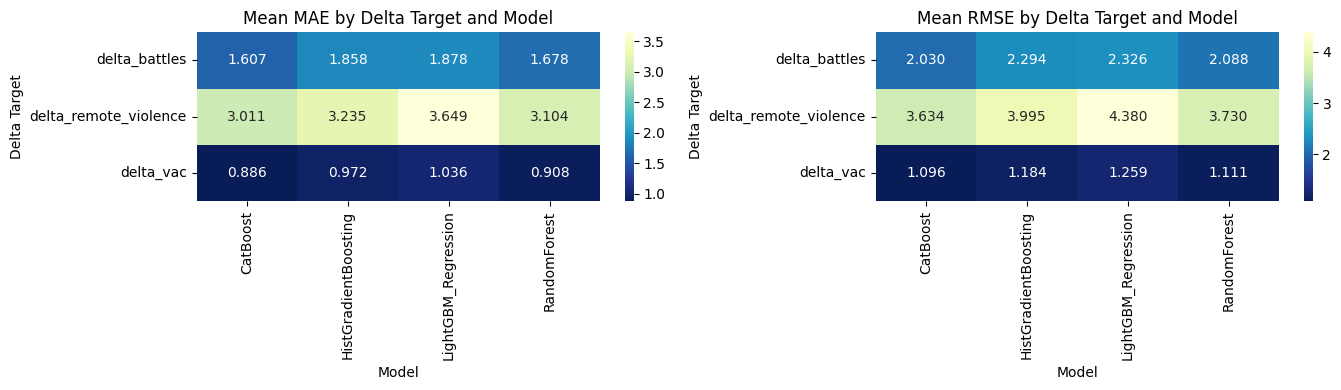

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, ['mae', 'rmse']):
    heatmap_data = results_df.pivot_table(
        index='target',
        columns='model',
        values=metric,
        aggfunc='mean'
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='YlGnBu_r',
        ax=ax
    )

    ax.set_title(f'Mean {metric.upper()} by Delta Target and Model')
    ax.set_xlabel('Model')
    ax.set_ylabel('Delta Target')

plt.tight_layout()
plt.show()

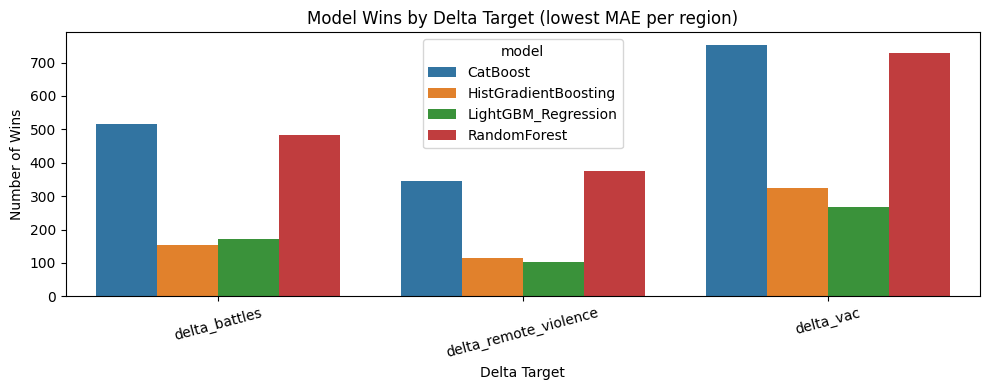

model,CatBoost,HistGradientBoosting,LightGBM_Regression,RandomForest
target,,,,
delta_battles,517,153,171,484
delta_remote_violence,346,115,102,376
delta_vac,753,324,268,730


In [13]:
wins = (
    results_df
    .loc[results_df.groupby(['region', 'target'])['mae'].idxmin()]
    .groupby(['target', 'model'])
    .size()
    .reset_index(name='wins')
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=wins,
    x='target',
    y='wins',
    hue='model'
)

plt.title('Model Wins by Delta Target (lowest MAE per region)')
plt.xlabel('Delta Target')
plt.ylabel('Number of Wins')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

wins.pivot(index='target', columns='model', values='wins').fillna(0).astype(int)

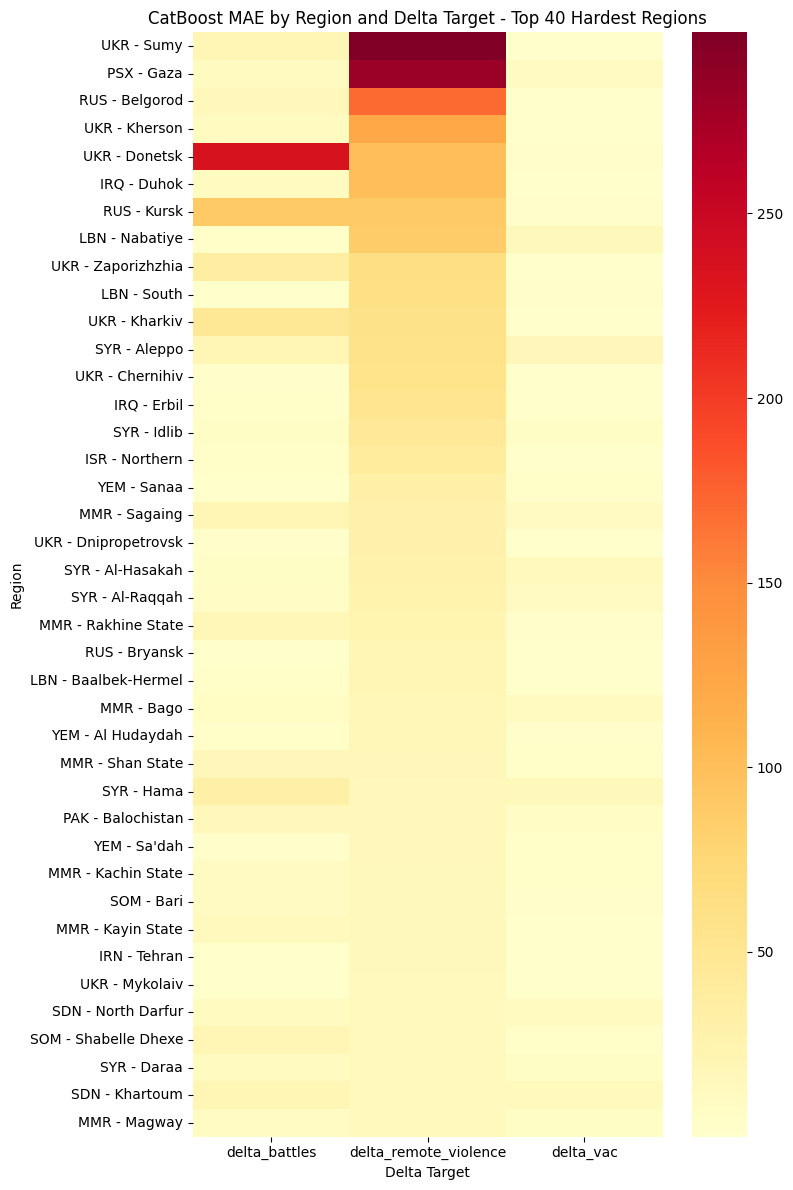

In [14]:
catboost_region_mae = (
    results_df[results_df['model'] == 'CatBoost']
    .pivot_table(
        index='region',
        columns='target',
        values='mae',
        aggfunc='mean'
    )
    .sort_values(by='delta_remote_violence', ascending=False)
    .head(40)
)

plt.figure(figsize=(8, 12))
sns.heatmap(
    catboost_region_mae,
    annot=False,
    cmap='YlOrRd'
)

plt.title('CatBoost MAE by Region and Delta Target - Top 40 Hardest Regions')
plt.xlabel('Delta Target')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

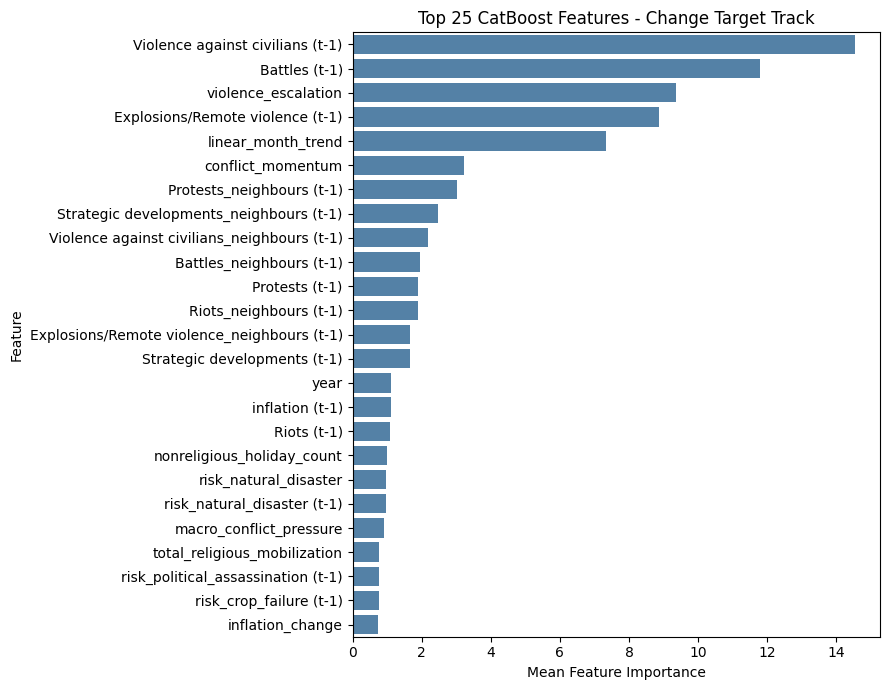

In [15]:
catboost_fi = [
    fi for (model_name, region, target), fi in feature_importances.items()
    if model_name == 'CatBoost'
]

if catboost_fi:
    catboost_fi_mean = (
        pd.concat(catboost_fi, axis=1)
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(25)
    )

    plt.figure(figsize=(9, 7))
    sns.barplot(
        x=catboost_fi_mean.values,
        y=catboost_fi_mean.index,
        color='steelblue'
    )

    plt.title('Top 25 CatBoost Features - Change Target Track')
    plt.xlabel('Mean Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No CatBoost feature importances collected.')

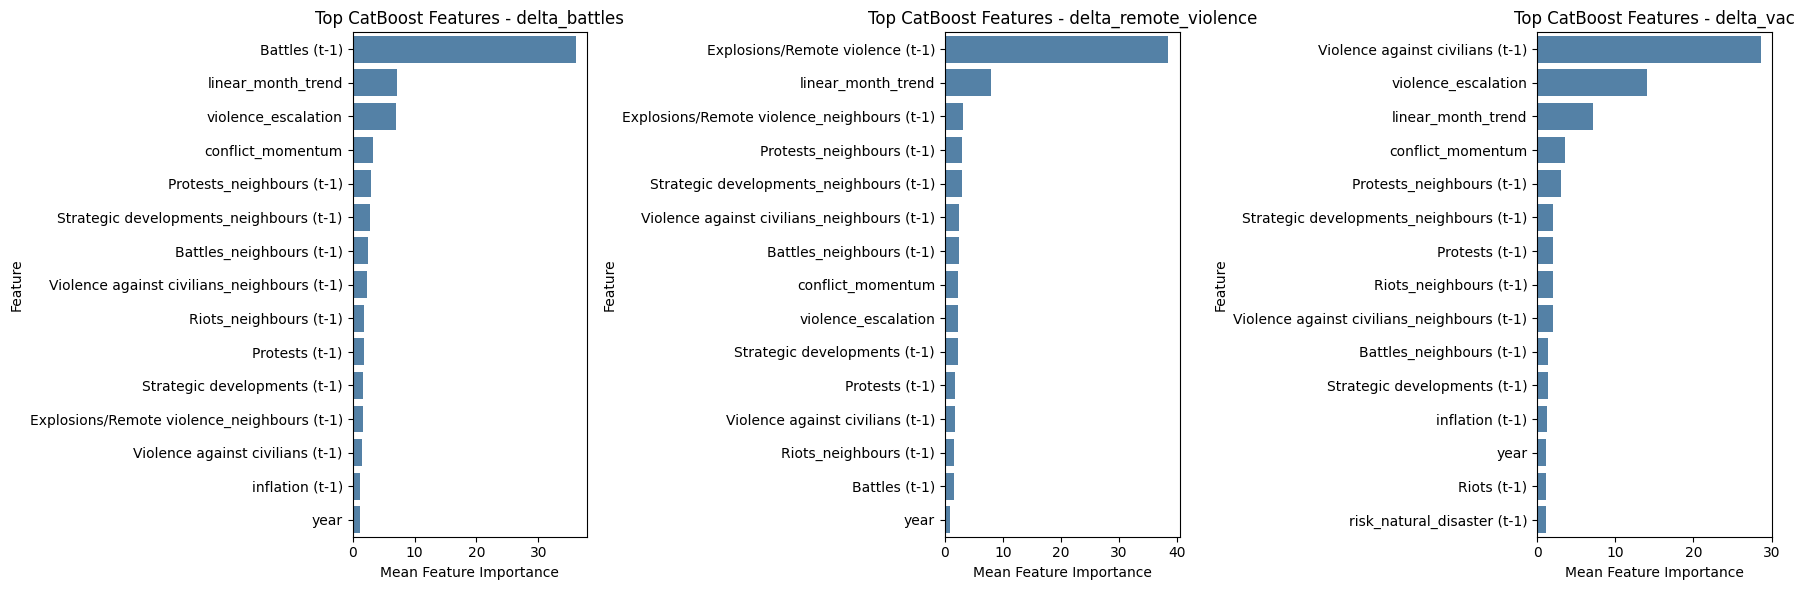

In [16]:
catboost_fi_by_target = {}

for target in DELTA_TARGETS:
    fi_list = [
        fi for (model_name, region, fi_target), fi in feature_importances.items()
        if model_name == 'CatBoost' and fi_target == target
    ]

    if fi_list:
        catboost_fi_by_target[target] = (
            pd.concat(fi_list, axis=1)
            .mean(axis=1)
            .sort_values(ascending=False)
            .head(15)
        )

fig, axes = plt.subplots(
    1,
    len(catboost_fi_by_target),
    figsize=(6 * len(catboost_fi_by_target), 6),
    sharex=False
)

if len(catboost_fi_by_target) == 1:
    axes = [axes]

for ax, (target, fi_values) in zip(axes, catboost_fi_by_target.items()):
    sns.barplot(
        x=fi_values.values,
        y=fi_values.index,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Top CatBoost Features - {target}')
    ax.set_xlabel('Mean Feature Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

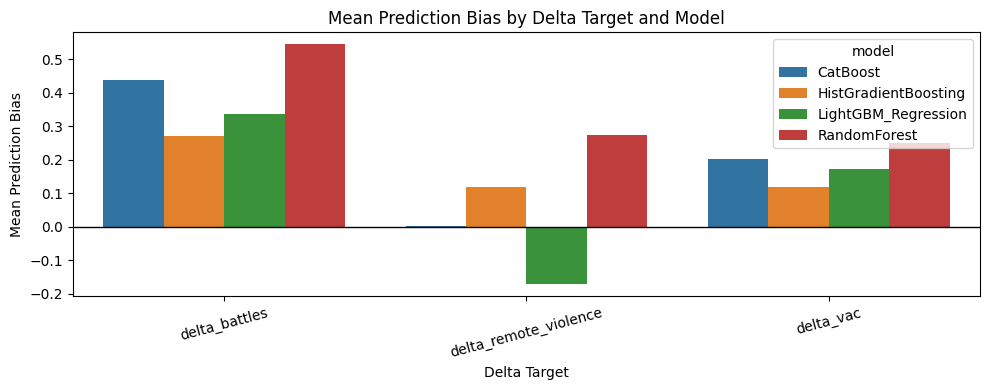

,target,model,bias
0,delta_battles,CatBoost,0.439
1,delta_battles,HistGradientBoosting,0.272
2,delta_battles,LightGBM_Regression,0.338
3,delta_battles,RandomForest,0.545
4,delta_remote_violence,CatBoost,0.003
5,delta_remote_violence,HistGradientBoosting,0.120
6,delta_remote_violence,LightGBM_Regression,-0.172
7,delta_remote_violence,RandomForest,0.274
8,delta_vac,CatBoost,0.202
9,delta_vac,HistGradientBoosting,0.120


In [17]:
bias_summary = results_df.copy()
bias_summary['bias'] = bias_summary['mean_pred'] - bias_summary['mean_actual']

bias_plot = (
    bias_summary
    .groupby(['target', 'model'])['bias']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=bias_plot,
    x='target',
    y='bias',
    hue='model'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Mean Prediction Bias by Delta Target and Model')
plt.xlabel('Delta Target')
plt.ylabel('Mean Prediction Bias')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

bias_plot.round(3)

In [18]:
country_hierarchy_data = model_data.reset_index().copy()

country_hierarchy_data['iso3'] = country_hierarchy_data['matched_admin1_id'].str.split(' - ').str[0]

country_targets = {
    'Battles': 'country_battles_excl (t-1)',
    'Explosions/Remote violence': 'country_remote_excl (t-1)',
    'Violence against civilians': 'country_vac_excl (t-1)',
}

for target, new_col in country_targets.items():
    country_month_total = (
        country_hierarchy_data
        .groupby(['iso3', 'month_year'])[target]
        .transform('sum')
    )

    country_hierarchy_data[new_col] = country_month_total - country_hierarchy_data[target]

country_hierarchy_data['country_total_excl (t-1)'] = (
    country_hierarchy_data[list(country_targets.values())].sum(axis=1)
)

country_hierarchy_cols = list(country_targets.values()) + ['country_total_excl (t-1)']

country_hierarchy_data = (
    country_hierarchy_data
    .sort_values(['matched_admin1_id', 'month_year'])
)

for col in country_hierarchy_cols:
    country_hierarchy_data[col] = (
        country_hierarchy_data
        .groupby('matched_admin1_id')[col]
        .shift(1)
    )

model_data_hierarchy = (
    country_hierarchy_data
    .set_index(['matched_admin1_id', 'month_year'])
    .sort_index()
)

country_hierarchy_cols


['country_battles_excl (t-1)',
 'country_remote_excl (t-1)',
 'country_vac_excl (t-1)',
 'country_total_excl (t-1)']

In [10]:
hierarchy_feature_cols = baseline_feature_cols + country_hierarchy_cols

RUN_REGIONS = VALID_REGIONS
RUN_TARGETS = DELTA_TARGETS

hierarchy_results = []

for region in RUN_REGIONS:
    region_data = model_data_hierarchy.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in RUN_TARGETS:
        train_pair = train_data[hierarchy_feature_cols + [target]].copy()
        test_pair = test_data[hierarchy_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        if y_train.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train_rf, X_test_rf = prepare_rf_inputs(
            train_pair, test_pair, hierarchy_feature_cols
        )

        X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
            train_pair, test_pair, hierarchy_feature_cols
        )

        model_specs = {
            'RandomForest_Hierarchy': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            'CatBoost_Hierarchy': CatBoostRegressor(
                iterations=500,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            ),
        }

        for model_name, model in model_specs.items():
            if model_name == 'RandomForest_Hierarchy':
                X_tr, X_te = X_train_rf, X_test_rf
                fit_kwargs = {}
                if weights is not None:
                    fit_kwargs['sample_weight'] = weights.values

            else:
                X_tr, X_te = X_train_cb, X_test_cb
                fit_kwargs = {}
                if cat_cols_cb is not None:
                    fit_kwargs['cat_features'] = cat_cols_cb
                if weights is not None:
                    fit_kwargs['sample_weight'] = weights.values

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X_tr, y_train, **fit_kwargs)

            y_pred = model.predict(X_te)

            hierarchy_results.append({
                'region': region,
                'target': target,
                'model': model_name,
                'mae': mean_absolute_error(y_test, y_pred),
                'rmse': rmse(y_test, y_pred),
                'mean_actual': y_test.mean(),
                'mean_pred': float(np.mean(y_pred)),
            })

hierarchy_results_df = pd.DataFrame(hierarchy_results)

print(f"Rows collected: {len(hierarchy_results_df)}")
hierarchy_results_df.head()

Rows collected: 8678


,region,target,model,mae,rmse,mean_actual,mean_pred
0,AFG - Badakhshan,delta_battles,RandomForest_Hierarchy,0.896667,1.024522,0.333333,0.261111
1,AFG - Badakhshan,delta_battles,CatBoost_Hierarchy,0.950693,1.071522,0.333333,-0.092627
2,AFG - Badakhshan,delta_remote_violence,RandomForest_Hierarchy,0.372222,0.484198,0.000000,0.372222
3,AFG - Badakhshan,delta_remote_violence,CatBoost_Hierarchy,0.253841,0.299636,0.000000,0.226077
4,AFG - Badakhshan,delta_vac,RandomForest_Hierarchy,1.353333,1.556211,-0.500000,-0.087778


In [12]:
hierarchy_summary = (
    hierarchy_results_df
    .groupby(['model', 'target'])[['mae', 'rmse']]
    .mean()
    .round(3)
)

hierarchy_summary

mae   rmse
model                  target                             
CatBoost_Hierarchy     delta_battles          1.589  2.014
                       delta_remote_violence  3.016  3.616
                       delta_vac              0.883  1.091
RandomForest_Hierarchy delta_battles          1.685  2.097
                       delta_remote_violence  3.149  3.758
                       delta_vac              0.902  1.104

In [13]:
baseline_summary_manual = pd.DataFrame({
    'model': [
        'CatBoost', 'CatBoost', 'CatBoost',
        'RandomForest', 'RandomForest', 'RandomForest',
    ],
    'target': [
        'delta_battles', 'delta_remote_violence', 'delta_vac',
        'delta_battles', 'delta_remote_violence', 'delta_vac',
    ],
    'mae': [
        1.607, 3.011, 0.886,
        1.678, 3.104, 0.908,
    ],
    'rmse': [
        2.030, 3.634, 1.096,
        2.088, 3.730, 1.111,
    ],
})

compare_hierarchy = pd.concat(
    [baseline_summary_manual, hierarchy_summary.reset_index()],
    ignore_index=True
)

compare_hierarchy.sort_values(['target', 'model'])

,model,target,mae,rmse
0,CatBoost,delta_battles,1.607,2.030
6,CatBoost_Hierarchy,delta_battles,1.589,2.014
3,RandomForest,delta_battles,1.678,2.088
9,RandomForest_Hierarchy,delta_battles,1.685,2.097
1,CatBoost,delta_remote_violence,3.011,3.634
7,CatBoost_Hierarchy,delta_remote_violence,3.016,3.616
4,RandomForest,delta_remote_violence,3.104,3.730
10,RandomForest_Hierarchy,delta_remote_violence,3.149,3.758
2,CatBoost,delta_vac,0.886,1.096
8,CatBoost_Hierarchy,delta_vac,0.883,1.091


In [14]:
hierarchy_mae_compare = compare_hierarchy.pivot(
    index='target',
    columns='model',
    values='mae'
)

hierarchy_mae_compare['RF_hierarchy_improvement_%'] = (
    (hierarchy_mae_compare['RandomForest'] - hierarchy_mae_compare['RandomForest_Hierarchy'])
    / hierarchy_mae_compare['RandomForest']
    * 100
).round(2)

hierarchy_mae_compare['CatBoost_hierarchy_improvement_%'] = (
    (hierarchy_mae_compare['CatBoost'] - hierarchy_mae_compare['CatBoost_Hierarchy'])
    / hierarchy_mae_compare['CatBoost']
    * 100
).round(2)

hierarchy_mae_compare

model,CatBoost,CatBoost_Hierarchy,RandomForest,RandomForest_Hierarchy,RF_hierarchy_improvement_%,CatBoost_hierarchy_improvement_%
target,,,,,,
delta_battles,1.607,1.589,1.678,1.685,-0.42,1.12
delta_remote_violence,3.011,3.016,3.104,3.149,-1.45,-0.17
delta_vac,0.886,0.883,0.908,0.902,0.66,0.34


**conclusion** : 
We tested country hierarchy features, but they did not meaningfully improve the change-target model. Because the average gain was only around 0.3% and one target got slightly worse, we will not prioritize this direction further in this notebook

## Holiday Alignment Experiments 

This section tests whether holiday timing can improve the signed change-target model.

The baseline notebook already excludes lagged holiday features and keeps current-month holiday features, because holidays are known calendar events rather than historical signals.

Here we test two additional holiday ideas:

1. next-month holiday alignment, because future holidays are known in advance
2. historical same-month conflict memory using t-12, t-24, and t-36 conflict values

The goal is to see whether CatBoost improves when holiday timing is represented more explicitly.

In [9]:
# 1. Next-month holiday alignment.

model_data = model_data.sort_index()

next_month_holiday_features = []
for col in holiday_current_features:
    next_col = f'next_month_{col}'
    model_data[next_col] = model_data.groupby(level=0)[col].shift(-1)
    next_month_holiday_features.append(next_col)

model_data[next_month_holiday_features] = model_data[next_month_holiday_features].fillna(0)
model_data[next_month_holiday_features].head()

next_month_christian_holiday_count  \
matched_admin1_id month_year                                       
ABW - Aruba       2018-01                                    0.0   
                  2018-02                                    1.0   
                  2018-03                                    1.0   
                  2018-04                                    1.0   
                  2018-05                                    0.0   

                              next_month_islam_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                0.0   
                  2018-02                                0.0   
                  2018-03                                0.0   
                  2018-04                                0.0   
                  2018-05                                0.0   

                              next_month_shia_holiday_count  \
matched_admin1_id month_year                                  
ABW - Aruba       2018-01                               0.0   
                  2018-02                               0.0   
                  2018-03                               0.0   
                  2018-04                               0.0   
                  2018-05                               0.0   

                              next_month_hindu_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                0.0   
                  2018-02                                0.0   
                  2018-03                                0.0   
                  2018-04                                0.0   
                  2018-05                                0.0   

                              next_month_buddhist_holiday_count  \
matched_admin1_id month_year                                      
ABW - Aruba       2018-01                                   0.0   
                  2018-02                                   0.0   
                  2018-03                                   0.0   
                  2018-04                                   0.0   
                  2018-05                                   0.0   

                              next_month_jewish_holiday_count  \
matched_admin1_id month_year                                    
ABW - Aruba       2018-01                                 0.0   
                  2018-02                                 0.0   
                  2018-03                                 0.0   
                  2018-04                                 0.0   
                  2018-05                                 0.0   

                              next_month_cultural_holiday_count  \
matched_admin1_id month_year                                      
ABW - Aruba       2018-01                                   0.0   
                  2018-02                                   0.0   
                  2018-03                                   0.0   
                  2018-04                                   0.0   
                  2018-05                                   0.0   

                              next_month_nonreligious_holiday_count  
matched_admin1_id month_year                                         
ABW - Aruba       2018-01                                       1.0  
                  2018-02                                       1.0  
                  2018-03                                       1.0  
                  2018-04                                       1.0  
                  2018-05                                       0.0

In [10]:
# Historical same-month conflict memory.

holiday_memory_features = []
memory_map = {
    'Battles': 'holiday_memory_battles_3yr',
    'Explosions/Remote violence': 'holiday_memory_remote_3yr',
    'Violence against civilians': 'holiday_memory_vac_3yr',
}

for raw_target, memory_col in memory_map.items():
    history_cols = []
    for lag in (12, 24, 36):
        lag_col = f'{raw_target} (t-{lag})'
        model_data[lag_col] = model_data.groupby(level=0)[raw_target].shift(lag)
        history_cols.append(lag_col)
    model_data[memory_col] = model_data[history_cols].mean(axis=1).fillna(0)
    holiday_memory_features.append(memory_col)

model_data['holiday_memory_total_3yr'] = model_data[holiday_memory_features].sum(axis=1)
holiday_memory_features.append('holiday_memory_total_3yr')

next_month_holiday_count_features = [c for c in next_month_holiday_features if c.endswith('holiday_count')]
model_data['next_month_total_holiday_count'] = model_data[next_month_holiday_count_features].sum(axis=1)

holiday_memory_interactions = []
for memory_col in holiday_memory_features:
    interaction_col = f'next_month_holiday_x_{memory_col}'
    model_data[interaction_col] = model_data['next_month_total_holiday_count'] * model_data[memory_col]
    holiday_memory_interactions.append(interaction_col)

model_data[holiday_memory_features + ['next_month_total_holiday_count'] + holiday_memory_interactions].head()

holiday_memory_battles_3yr  \
matched_admin1_id month_year                               
ABW - Aruba       2018-01                            0.0   
                  2018-02                            0.0   
                  2018-03                            0.0   
                  2018-04                            0.0   
                  2018-05                            0.0   

                              holiday_memory_remote_3yr  \
matched_admin1_id month_year                              
ABW - Aruba       2018-01                           0.0   
                  2018-02                           0.0   
                  2018-03                           0.0   
                  2018-04                           0.0   
                  2018-05                           0.0   

                              holiday_memory_vac_3yr  \
matched_admin1_id month_year                           
ABW - Aruba       2018-01                        0.0   
                  2018-02                        0.0   
                  2018-03                        0.0   
                  2018-04                        0.0   
                  2018-05                        0.0   

                              holiday_memory_total_3yr  \
matched_admin1_id month_year                             
ABW - Aruba       2018-01                          0.0   
                  2018-02                          0.0   
                  2018-03                          0.0   
                  2018-04                          0.0   
                  2018-05                          0.0   

                              next_month_total_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                1.0   
                  2018-02                                2.0   
                  2018-03                                2.0   
                  2018-04                                2.0   
                  2018-05                                0.0   

                              next_month_holiday_x_holiday_memory_battles_3yr  \
matched_admin1_id month_year                                                    
ABW - Aruba       2018-01                                                 0.0   
                  2018-02                                                 0.0   
                  2018-03                                                 0.0   
                  2018-04                                                 0.0   
                  2018-05                                                 0.0   

                              next_month_holiday_x_holiday_memory_remote_3yr  \
matched_admin1_id month_year                                                   
ABW - Aruba       2018-01                                                0.0   
                  2018-02                                                0.0   
                  2018-03                                                0.0   
                  2018-04                                                0.0   
                  2018-05                                                0.0   

                              next_month_holiday_x_holiday_memory_vac_3yr  \
matched_admin1_id month_year                                                
ABW - Aruba       2018-01                                             0.0   
                  2018-02                                             0.0   
                  2018-03                                             0.0   
                  2018-04                                             0.0   
                  2018-05                                             0.0   

                              next_month_holiday_x_holiday_memory_total_3yr  
matched_admin1_id month_year                                                 
ABW - Aruba       2018-01                                               0.0  
                  2018-02                  

In [11]:
model_data[
    model_data['holiday_memory_total_3yr'] > 0
][holiday_memory_features + ['next_month_total_holiday_count'] + holiday_memory_interactions].head()

holiday_memory_battles_3yr  \
matched_admin1_id month_year                               
AFG - Badakhshan  2019-01                            1.0   
                  2019-02                            6.0   
                  2019-03                            5.0   
                  2019-04                           12.0   
                  2019-05                           27.0   

                              holiday_memory_remote_3yr  \
matched_admin1_id month_year                              
AFG - Badakhshan  2019-01                           2.0   
                  2019-02                           4.0   
                  2019-03                           3.0   
                  2019-04                           4.0   
                  2019-05                           9.0   

                              holiday_memory_vac_3yr  \
matched_admin1_id month_year                           
AFG - Badakhshan  2019-01                        1.0   
                  2019-02                        0.0   
                  2019-03                        2.0   
                  2019-04                        0.0   
                  2019-05                        0.0   

                              holiday_memory_total_3yr  \
matched_admin1_id month_year                             
AFG - Badakhshan  2019-01                          4.0   
                  2019-02                         10.0   
                  2019-03                         10.0   
                  2019-04                         16.0   
                  2019-05                         36.0   

                              next_month_total_holiday_count  \
matched_admin1_id month_year                                   
AFG - Badakhshan  2019-01                                1.0   
                  2019-02                                1.0   
                  2019-03                                2.0   
                  2019-04                                3.0   
                  2019-05                                2.0   

                              next_month_holiday_x_holiday_memory_battles_3yr  \
matched_admin1_id month_year                                                    
AFG - Badakhshan  2019-01                                                 1.0   
                  2019-02                                                 6.0   
                  2019-03                                                10.0   
                  2019-04                                                36.0   
                  2019-05                                                54.0   

                              next_month_holiday_x_holiday_memory_remote_3yr  \
matched_admin1_id month_year                                                   
AFG - Badakhshan  2019-01                                                2.0   
                  2019-02                                                4.0   
                  2019-03                                                6.0   
                  2019-04                                               12.0   
                  2019-05                                               18.0   

                              next_month_holiday_x_holiday_memory_vac_3yr  \
matched_admin1_id month_year                                                
AFG - Badakhshan  2019-01                                             1.0   
                  2019-02                                             0.0   
                  2019-03                                             4.0   
                  2019-04                                             0.0   
                  2019-05                                             0.0   

                              next_month_holiday_x_holiday_memory_total_3yr  
matched_admin1_id month_year                                                 
AFG - Badakhshan  2019-01                                               4.0  
                  2019-02                  

In [18]:
holiday_enhanced_feature_cols = list(dict.fromkeys(
    baseline_feature_cols
    + next_month_holiday_features
    + holiday_memory_features
    + holiday_memory_interactions
))

catboost_variants = {
    'CatBoost_baseline': baseline_feature_cols,
    'CatBoost_holiday_enhanced': holiday_enhanced_feature_cols,
}

catboost_compare_results = []

for i, region in enumerate(VALID_REGIONS, start=1):
    if i % 100 == 0:
        print(f"Processed {i}/{len(VALID_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        for variant_name, feature_cols in catboost_variants.items():
            train_pair = train_data[feature_cols + [target]].copy()
            test_pair = test_data[feature_cols + [target]].copy()

            train_pair = train_pair[train_pair[target].notna()]
            test_pair = test_pair[test_pair[target].notna()]

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test = test_pair[target]

            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]

            X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
                train_pair,
                test_pair,
                feature_cols,
            )

            model = CatBoostRegressor(
                iterations=500,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            fit_kwargs = {}
            if cat_cols_cb is not None:
                fit_kwargs['cat_features'] = cat_cols_cb
            if weights is not None:
                fit_kwargs['sample_weight'] = weights.values

            model.fit(X_train_cb, y_train, **fit_kwargs)
            y_pred = model.predict(X_test_cb)

            catboost_compare_results.append({
                'region': region,
                'target': target,
                'variant': variant_name,
                'mae': mean_absolute_error(y_test, y_pred),
                'rmse': rmse(y_test, y_pred),
                'mean_actual': y_test.mean(),
                'mean_pred': float(np.mean(y_pred)),
            })

catboost_compare_df = pd.DataFrame(catboost_compare_results)

catboost_summary = (
    catboost_compare_df
    .groupby(['variant', 'target'])[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
    .round(3)
)

baseline = catboost_summary.loc['CatBoost_baseline'][['mae', 'rmse']]

catboost_holiday_compare = catboost_summary[['mae', 'rmse']].join(
    baseline,
    on='target',
    rsuffix='_baseline',
)

catboost_holiday_compare['mae_improvement_pct'] = (
    (catboost_holiday_compare['mae_baseline'] - catboost_holiday_compare['mae'])
    / catboost_holiday_compare['mae_baseline']
    * 100
).round(2)

catboost_holiday_compare['rmse_improvement_pct'] = (
    (catboost_holiday_compare['rmse_baseline'] - catboost_holiday_compare['rmse'])
    / catboost_holiday_compare['rmse_baseline']
    * 100
).round(2)

catboost_holiday_compare.round(3)


Processed 100/2205 regions
Processed 200/2205 regions
Processed 300/2205 regions
Processed 400/2205 regions
Processed 500/2205 regions
Processed 600/2205 regions
Processed 700/2205 regions
Processed 800/2205 regions
Processed 900/2205 regions
Processed 1000/2205 regions
Processed 1100/2205 regions
Processed 1200/2205 regions
Processed 1300/2205 regions
Processed 1400/2205 regions
Processed 1500/2205 regions
Processed 1600/2205 regions
Processed 1700/2205 regions
Processed 1800/2205 regions
Processed 1900/2205 regions
Processed 2000/2205 regions
Processed 2100/2205 regions
Processed 2200/2205 regions


mae   rmse  mae_baseline  \
variant                   target                                              
CatBoost_baseline         delta_battles          1.607  2.030         1.607   
                          delta_remote_violence  3.011  3.634         3.011   
                          delta_vac              0.886  1.096         0.886   
CatBoost_holiday_enhanced delta_battles          1.621  2.053         1.607   
                          delta_remote_violence  3.001  3.733         3.011   
                          delta_vac              0.893  1.101         0.886   

                                                 rmse_baseline  \
variant                   target                                 
CatBoost_baseline         delta_battles                  2.030   
                          delta_remote_violence          3.634   
                          delta_vac                      1.096   
CatBoost_holiday_enhanced delta_battles                  2.030   
                          delta_remote_violence          3.634   
                          delta_vac                      1.096   

                                                 mae_improvement_pct  \
variant                   target                                       
CatBoost_baseline         delta_battles                         0.00   
                          delta_remote_violence                 0.00   
                          delta_vac                             0.00   
CatBoost_holiday_enhanced delta_battles                        -0.87   
                          delta_remote_violence                 0.33   
                          delta_vac                            -0.79   

                                                 rmse_improvement_pct  
variant                   target                                       
CatBoost_baseline         delta_battles                          0.00  
                          delta_remote_violence                  0.00  
                          delta_vac                              0.00  
CatBoost_holiday_enhanced delta_battles                         -1.13  
                          delta_remote_violence                 -2.72  
                          delta_vac                             -0.46

In [22]:
RUN_REGIONS = VALID_REGIONS[:100]
TOP_N = 20

catboost_fi_results = []

for variant_name, feature_cols in catboost_variants.items():
    print(f"Collecting feature importance for {variant_name}")

    feature_cols = list(dict.fromkeys(feature_cols))

    for i, region in enumerate(RUN_REGIONS, start=1):
        if i % 25 == 0:
            print(f"{variant_name}: {i}/{len(RUN_REGIONS)} regions")

        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            train_pair = train_data[feature_cols + [target]].copy()
            train_pair = train_pair[train_pair[target].notna()]

            if len(train_pair) == 0:
                continue

            y_train = train_pair[target]

            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]

            X_train_cb, _, cat_cols_cb = prepare_catboost_inputs(
                train_pair,
                train_pair,
                feature_cols,
            )

            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            fit_kwargs = {}
            if cat_cols_cb is not None:
                fit_kwargs['cat_features'] = cat_cols_cb
            if weights is not None:
                fit_kwargs['sample_weight'] = weights.values

            model.fit(X_train_cb, y_train, **fit_kwargs)

            fi = pd.DataFrame({
                'variant': variant_name,
                'target': target,
                'region': region,
                'feature': feature_cols,
                'importance': model.feature_importances_,
            })

            catboost_fi_results.append(fi)

catboost_fi_df = pd.concat(catboost_fi_results, ignore_index=True)

catboost_fi_summary = (
    catboost_fi_df
    .groupby(['variant', 'target', 'feature'])['importance']
    .mean()
    .reset_index()
)

catboost_fi_summary

CatBoost_baseline: 25/100 regions
CatBoost_baseline: 50/100 regions
CatBoost_baseline: 75/100 regions
CatBoost_baseline: 100/100 regions
CatBoost_holiday_enhanced: 25/100 regions
CatBoost_holiday_enhanced: 50/100 regions
CatBoost_holiday_enhanced: 75/100 regions
CatBoost_holiday_enhanced: 100/100 regions


,variant,target,feature,importance
0,CatBoost_baseline,delta_battles,Agreement (t-1),0.822994
1,CatBoost_baseline,delta_battles,Battles (t-1),25.981532
2,CatBoost_baseline,delta_battles,Battles_neighbours (t-1),5.655613
3,CatBoost_baseline,delta_battles,Excessive force against protesters (t-1),0.010824
4,CatBoost_baseline,delta_battles,Explosions/Remote violence (t-1),3.178743
...,...,...,...,...
523,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_majority,0.270838
524,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_minority1,0.304652
525,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_minority2,0.379328
526,CatBoost_holiday_enhanced,delta_vac,year,0.717462


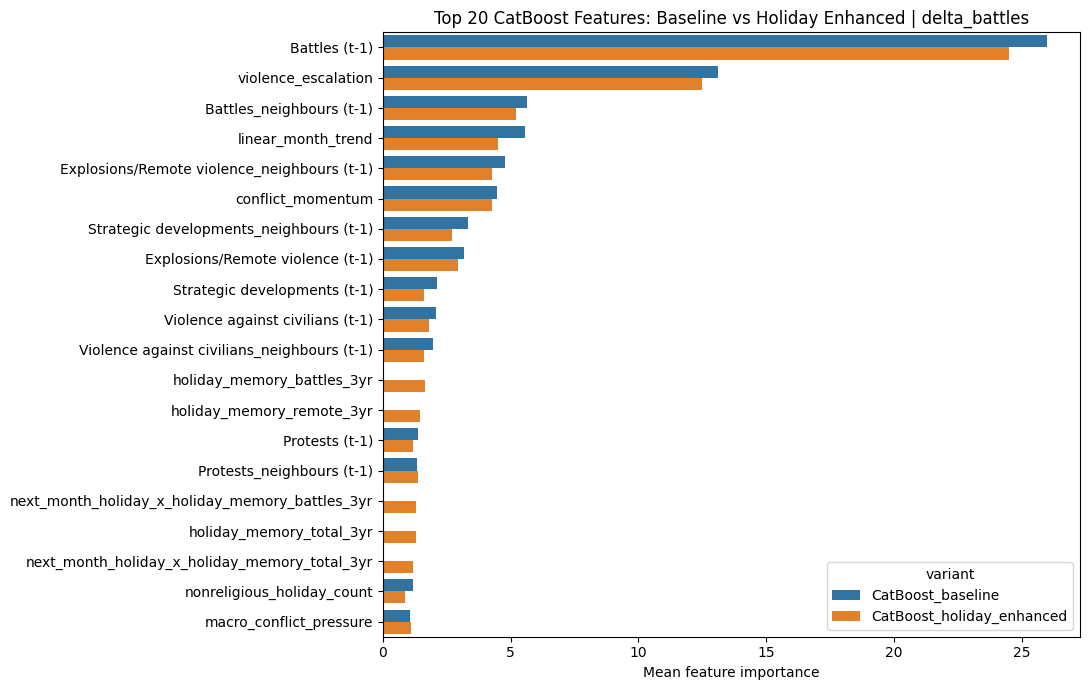

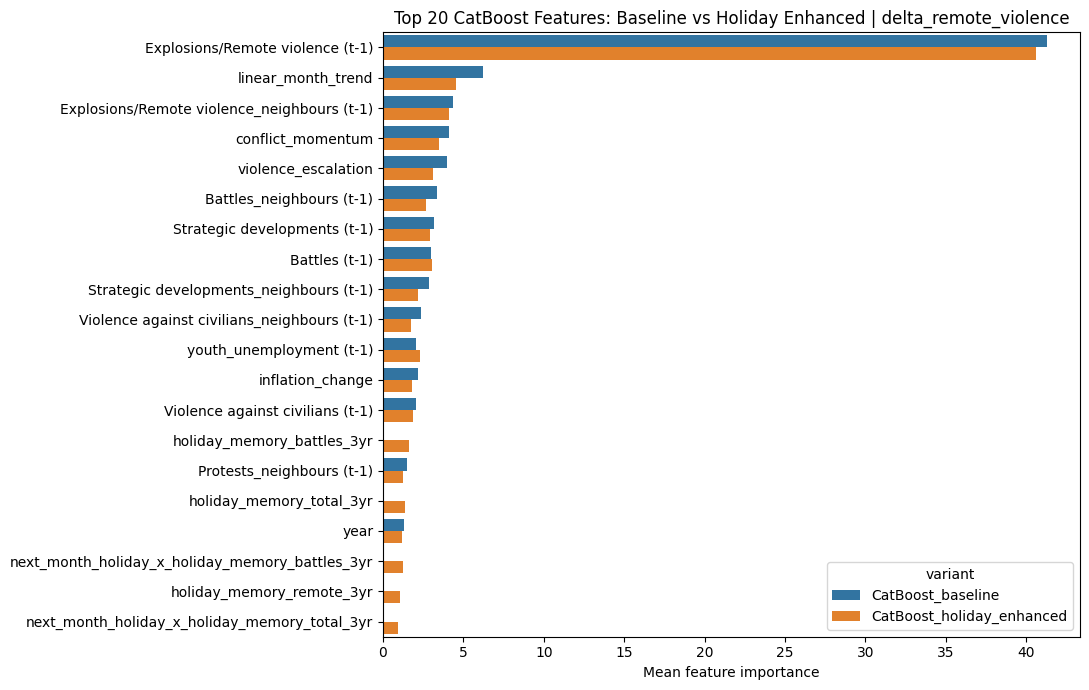

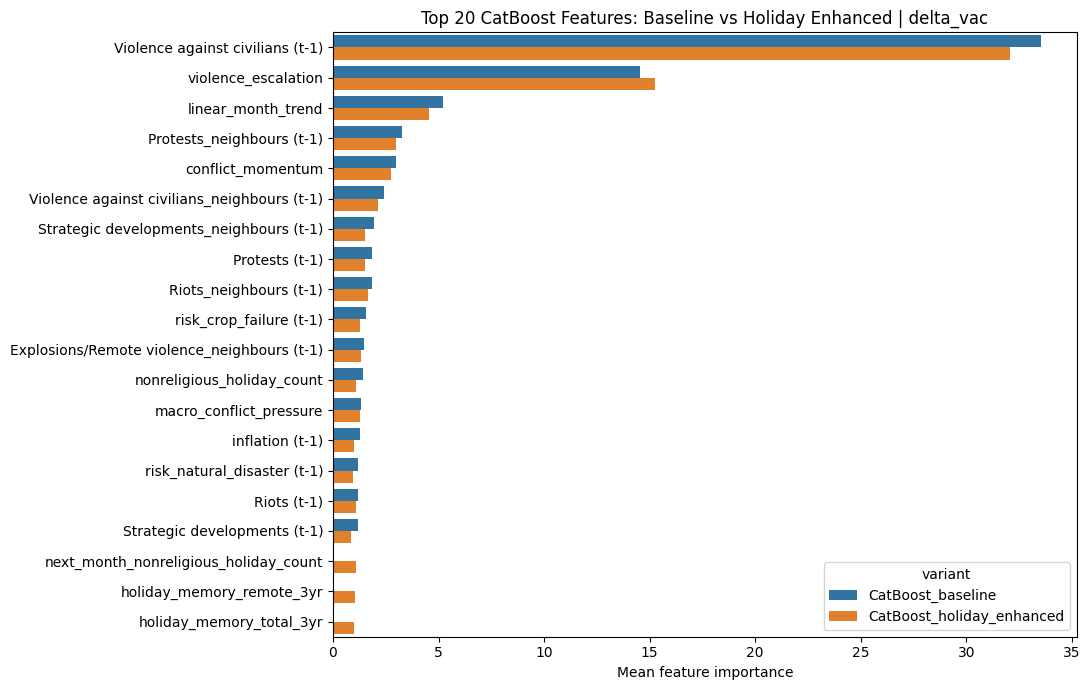

In [23]:
for target in DELTA_TARGETS:
    top_features = (
        catboost_fi_summary[catboost_fi_summary['target'] == target]
        .groupby('feature')['importance']
        .max()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    plot_df = catboost_fi_summary[
        (catboost_fi_summary['target'] == target)
        & (catboost_fi_summary['feature'].isin(top_features))
    ].copy()

    order = (
        plot_df.groupby('feature')['importance']
        .max()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(11, 7))
    sns.barplot(
        data=plot_df,
        y='feature',
        x='importance',
        hue='variant',
        order=order,
    )
    plt.title(f'Top {TOP_N} CatBoost Features: Baseline vs Holiday Enhanced | {target}')
    plt.xlabel('Mean feature importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [24]:
# Phase 1: Persistence baseline for change targets
# For delta targets, persistence means "no change", so predicted delta = 0.

persistence_results = []

for region in VALID_REGIONS:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    for target in DELTA_TARGETS:
        y_test = test_data[target].dropna()

        if len(y_test) == 0:
            continue

        y_pred = np.zeros(len(y_test))

        persistence_results.append({
            'region': region,
            'target': target,
            'model': 'Persistence_no_change',
            'mae': mean_absolute_error(y_test, y_pred),
            'rmse': rmse(y_test, y_pred),
            'mean_actual': y_test.mean(),
            'mean_pred': float(np.mean(y_pred)),
        })

persistence_results_df = pd.DataFrame(persistence_results)

persistence_summary = (
    persistence_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
    .round(3)
)

persistence_summary

,mae,rmse,mean_actual,mean_pred
target,,,,
delta_battles,0.902,1.162,-0.147,0.0
delta_remote_violence,1.119,1.413,-0.088,0.0
delta_vac,0.771,0.984,-0.084,0.0


In [25]:
# Compare CatBoost against persistence

catboost_baseline_results_df = (
    catboost_compare_df[catboost_compare_df['variant'] == 'CatBoost_baseline']
    .copy()
)

catboost_baseline_results_df['model'] = 'CatBoost'

catboost_summary = (
    catboost_baseline_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
)

persistence_summary_raw = (
    persistence_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
)

persistence_compare = catboost_summary[['mae', 'rmse']].join(
    persistence_summary_raw[['mae', 'rmse']],
    rsuffix='_persistence'
)

persistence_compare['mae_improvement_pct_vs_persistence'] = (
    (persistence_compare['mae_persistence'] - persistence_compare['mae'])
    / persistence_compare['mae_persistence']
    * 100
)

persistence_compare['rmse_improvement_pct_vs_persistence'] = (
    (persistence_compare['rmse_persistence'] - persistence_compare['rmse'])
    / persistence_compare['rmse_persistence']
    * 100
)

persistence_compare.round(3)

,mae,rmse,mae_persistence,rmse_persistence,mae_improvement_pct_vs_persistence,rmse_improvement_pct_vs_persistence
target,,,,,,
delta_battles,1.607,2.030,0.902,1.162,-78.251,-74.690
delta_remote_violence,3.011,3.634,1.119,1.413,-169.070,-157.187
delta_vac,0.886,1.096,0.771,0.984,-14.882,-11.373


In [26]:
combined_persistence_score = pd.DataFrame({
    'catboost_mean_mae': [persistence_compare['mae'].mean()],
    'persistence_mean_mae': [persistence_compare['mae_persistence'].mean()],
    'catboost_mean_rmse': [persistence_compare['rmse'].mean()],
    'persistence_mean_rmse': [persistence_compare['rmse_persistence'].mean()],
})

combined_persistence_score['mean_mae_improvement_pct_vs_persistence'] = (
    (combined_persistence_score['persistence_mean_mae'] - combined_persistence_score['catboost_mean_mae'])
    / combined_persistence_score['persistence_mean_mae']
    * 100
)

combined_persistence_score['mean_rmse_improvement_pct_vs_persistence'] = (
    (combined_persistence_score['persistence_mean_rmse'] - combined_persistence_score['catboost_mean_rmse'])
    / combined_persistence_score['persistence_mean_rmse']
    * 100
)

combined_persistence_score.round(3)


,catboost_mean_mae,persistence_mean_mae,catboost_mean_rmse,persistence_mean_rmse,mean_mae_improvement_pct_vs_persistence,mean_rmse_improvement_pct_vs_persistence
0,1.835,0.931,2.253,1.186,-97.156,-89.936


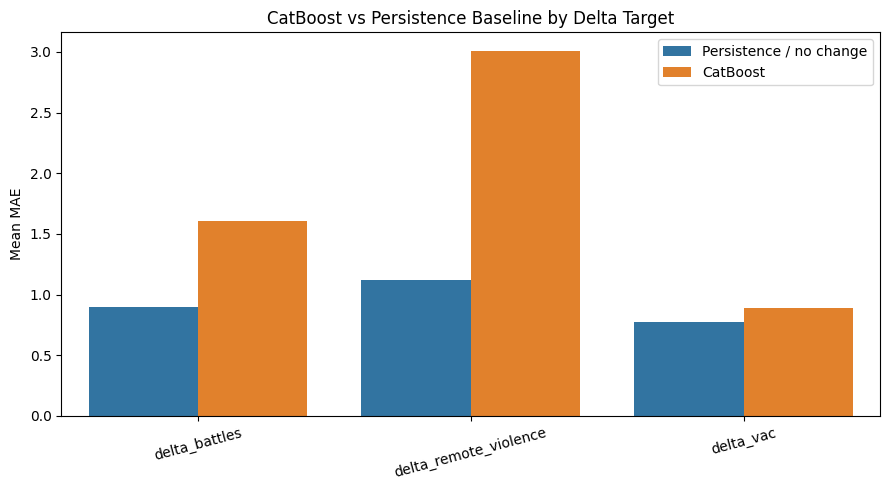

In [28]:
plot_df = (
    persistence_compare
    .reset_index()
    [['target', 'mae_persistence', 'mae']]
    .rename(columns={
        'mae_persistence': 'Persistence / no change',
        'mae': 'CatBoost'
    })
    .melt(
        id_vars='target',
        var_name='model',
        value_name='MAE'
    )
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x='target',
    y='MAE',
    hue='model'
)

plt.title('CatBoost vs Persistence Baseline by Delta Target')
plt.xlabel('')
plt.ylabel('Mean MAE')
plt.xticks(rotation=15)
plt.legend(title='')
plt.tight_layout()
plt.show()

**finding** : The persistence baseline performs strongly because most delta targets are zero, so predicting “no change” is often correct. This does not necessarily mean CatBoost is unhelpful; rather, full-sample MAE rewards conservative zero predictions. The next evaluation should separate zero-delta months from nonzero-delta months to test whether CatBoost adds value on actual escalation/de-escalation cases.


In [29]:
# Split evaluation on zero-delta vs nonzero-delta rows
# Diagnostic only: small subset, not full final run.

RUN_REGIONS = VALID_REGIONS[:100]

split_eval_rows = []

for i, region in enumerate(RUN_REGIONS, start=1):
    if i % 25 == 0:
        print(f"Processed {i}/{len(RUN_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_data[baseline_feature_cols + [target]].copy()
        test_pair = test_data[baseline_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        if y_train.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
            train_pair,
            test_pair,
            baseline_feature_cols,
        )

        model = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )

        fit_kwargs = {}
        if cat_cols_cb is not None:
            fit_kwargs['cat_features'] = cat_cols_cb
        if weights is not None:
            fit_kwargs['sample_weight'] = weights.values

        model.fit(X_train_cb, y_train, **fit_kwargs)
        catboost_pred = model.predict(X_test_cb)

        for month, actual, pred in zip(y_test.index, y_test.values, catboost_pred):
            split_eval_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'actual_delta': actual,
                'model': 'CatBoost',
                'prediction': pred,
                'error_abs': abs(actual - pred),
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
            })

            split_eval_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'actual_delta': actual,
                'model': 'Persistence_no_change',
                'prediction': 0.0,
                'error_abs': abs(actual - 0.0),
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
            })

split_eval_df = pd.DataFrame(split_eval_rows)

split_eval_summary = (
    split_eval_df
    .groupby(['target', 'delta_group', 'model'])['error_abs']
    .mean()
    .reset_index()
    .rename(columns={'error_abs': 'mae'})
)

split_eval_summary

Processed 25/100 regions
Processed 50/100 regions
Processed 75/100 regions
Processed 100/100 regions


,target,delta_group,model,mae
0,delta_battles,nonzero_delta,CatBoost,2.618395
1,delta_battles,nonzero_delta,Persistence_no_change,2.762887
2,delta_battles,zero_delta,CatBoost,0.225760
3,delta_battles,zero_delta,Persistence_no_change,0.000000
4,delta_remote_violence,nonzero_delta,CatBoost,1.425314
5,delta_remote_violence,nonzero_delta,Persistence_no_change,1.661017
6,delta_remote_violence,zero_delta,CatBoost,0.153296
7,delta_remote_violence,zero_delta,Persistence_no_change,0.000000
8,delta_vac,nonzero_delta,CatBoost,1.497597
9,delta_vac,nonzero_delta,Persistence_no_change,1.708661


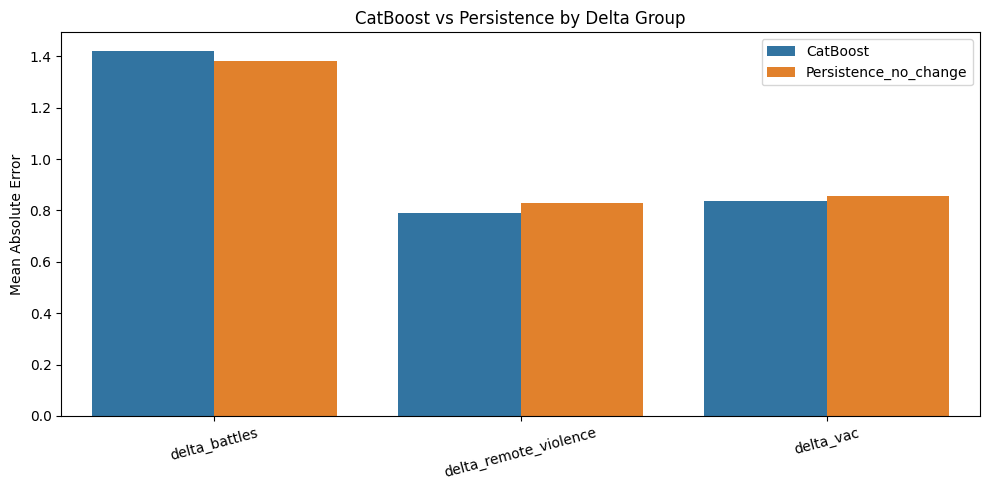

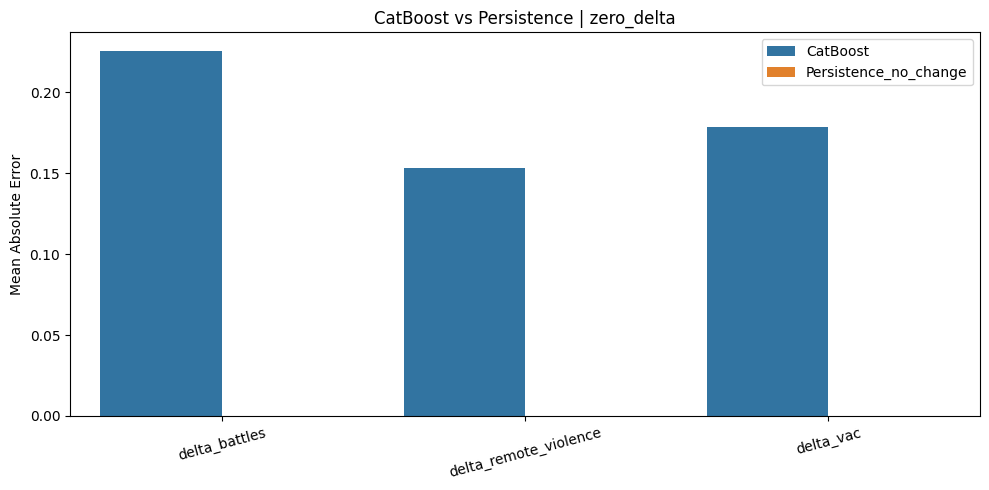

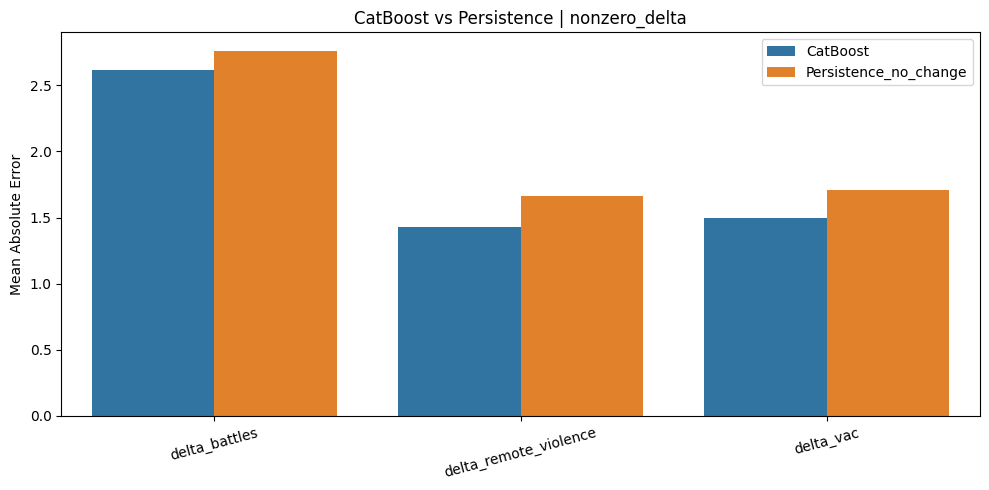

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=split_eval_summary,
    x='target',
    y='mae',
    hue='model',
    errorbar=None
)

plt.title('CatBoost vs Persistence by Delta Group')
plt.xlabel('')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=15)
plt.legend(title='')

plt.tight_layout()
plt.show()

for group in ['zero_delta', 'nonzero_delta']:
    group_df = split_eval_summary[split_eval_summary['delta_group'] == group]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=group_df,
        x='target',
        y='mae',
        hue='model',
        errorbar=None
    )
    plt.title(f'CatBoost vs Persistence | {group}')
    plt.xlabel('')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=15)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

## Two-Stage Change Model

The split evaluation showed that persistence is strongest on zero-delta months, while CatBoost performs better on nonzero-delta months. This motivates a two-stage model:

1. Stage 1: classify whether the target delta is nonzero.
2. Stage 2: predict the signed delta magnitude only for nonzero-change cases.
3. Combined prediction: use the Stage 2 regression prediction only when Stage 1 predicts change; otherwise predict zero.


In [31]:
# Diagnostic run only: small subset.

from catboost import CatBoostClassifier


RUN_REGIONS = VALID_REGIONS[:100]
CHANGE_THRESHOLD = 0.50

two_stage_rows = []

for i, region in enumerate(RUN_REGIONS, start=1):
    if i % 25 == 0:
        print(f"Processed {i}/{len(RUN_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_data[baseline_feature_cols + [target]].copy()
        test_pair = test_data[baseline_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        # Need both classes for Stage 1.
        y_train_binary = (y_train != 0).astype(int)
        if y_train_binary.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train, X_test, cat_cols = prepare_catboost_inputs(
            train_pair,
            test_pair,
            baseline_feature_cols,
        )

        fit_kwargs = {}
        if cat_cols is not None:
            fit_kwargs['cat_features'] = cat_cols
        if weights is not None:
            fit_kwargs['sample_weight'] = weights.values

        # Stage 1: will this month have nonzero change?
        clf = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )

        clf.fit(X_train, y_train_binary, **fit_kwargs)
        change_prob = clf.predict_proba(X_test)[:, 1]
        change_flag = (change_prob >= CHANGE_THRESHOLD).astype(int)

        # Stage 2: signed magnitude, trained only on nonzero-change rows.
        nonzero_train_mask = y_train != 0

        if nonzero_train_mask.sum() < 5:
            # Not enough active rows to train the regressor safely.
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            X_train_nonzero = X_train.loc[nonzero_train_mask]
            y_train_nonzero = y_train.loc[nonzero_train_mask]

            reg_fit_kwargs = {}
            if cat_cols is not None:
                reg_fit_kwargs['cat_features'] = cat_cols
            if weights is not None:
                reg_fit_kwargs['sample_weight'] = weights.loc[nonzero_train_mask].values

            reg.fit(X_train_nonzero, y_train_nonzero, **reg_fit_kwargs)
            stage2_pred = reg.predict(X_test)

        two_stage_pred = change_flag * stage2_pred

        # One-stage CatBoost baseline on same small subset
        one_stage = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        one_stage.fit(X_train, y_train, **fit_kwargs)
        one_stage_pred = one_stage.predict(X_test)

        for month, actual, pred_two, pred_one, pred_persist, prob in zip(
            y_test.index,
            y_test.values,
            two_stage_pred,
            one_stage_pred,
            np.zeros(len(y_test)),
            change_prob,
        ):
            delta_group = 'nonzero_delta' if actual != 0 else 'zero_delta'

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'TwoStage_CatBoost',
                'actual_delta': actual,
                'prediction': pred_two,
                'change_prob': prob,
                'abs_error': abs(actual - pred_two),
            })

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'OneStage_CatBoost',
                'actual_delta': actual,
                'prediction': pred_one,
                'change_prob': np.nan,
                'abs_error': abs(actual - pred_one),
            })

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'Persistence_no_change',
                'actual_delta': actual,
                'prediction': pred_persist,
                'change_prob': np.nan,
                'abs_error': abs(actual - pred_persist),
            })

two_stage_eval_df = pd.DataFrame(two_stage_rows)

two_stage_summary = (
    two_stage_eval_df
    .groupby(['target', 'delta_group', 'model'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'mae'})
)

two_stage_summary


Processed 25/100 regions
Processed 50/100 regions
Processed 75/100 regions
Processed 100/100 regions


,target,delta_group,model,mae
0,delta_battles,nonzero_delta,OneStage_CatBoost,2.618395
1,delta_battles,nonzero_delta,Persistence_no_change,2.762887
2,delta_battles,nonzero_delta,TwoStage_CatBoost,2.627507
3,delta_battles,zero_delta,OneStage_CatBoost,0.225760
4,delta_battles,zero_delta,Persistence_no_change,0.000000
5,delta_battles,zero_delta,TwoStage_CatBoost,0.187043
6,delta_remote_violence,nonzero_delta,OneStage_CatBoost,1.425314
7,delta_remote_violence,nonzero_delta,Persistence_no_change,1.661017
8,delta_remote_violence,nonzero_delta,TwoStage_CatBoost,1.395778
9,delta_remote_violence,zero_delta,OneStage_CatBoost,0.153296


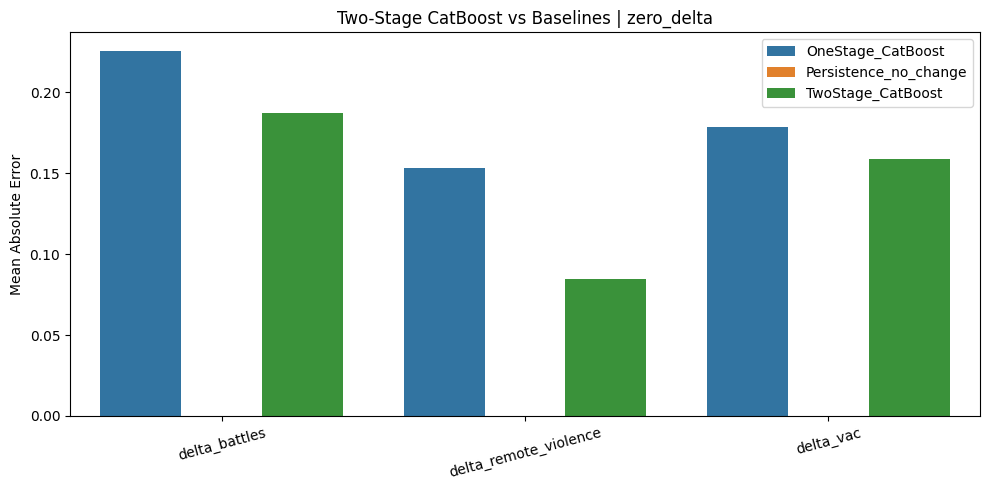

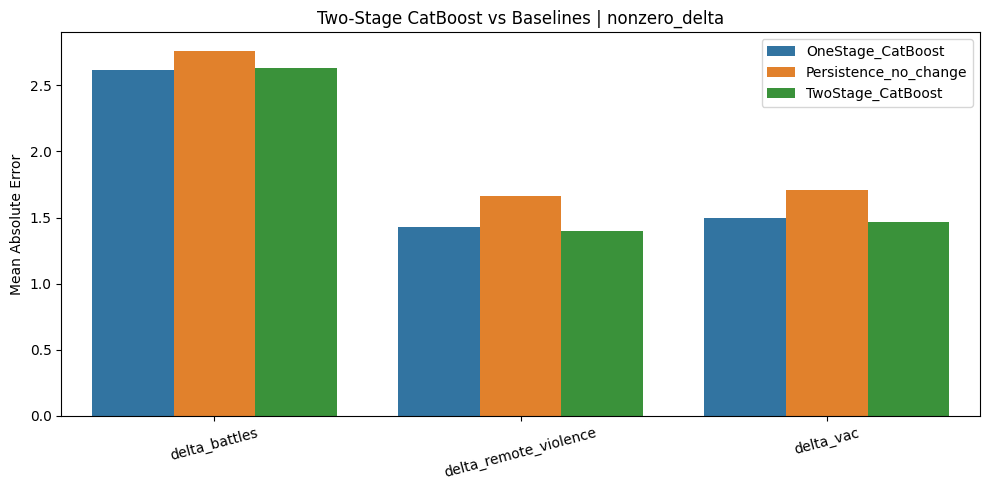

In [32]:
two_stage_compare = two_stage_summary.pivot_table(
    index=['target', 'delta_group'],
    columns='model',
    values='mae'
).reset_index()

two_stage_compare['two_stage_improvement_pct_vs_persistence'] = (
    (two_stage_compare['Persistence_no_change'] - two_stage_compare['TwoStage_CatBoost'])
    / two_stage_compare['Persistence_no_change']
    * 100
).round(2)

two_stage_compare['two_stage_improvement_pct_vs_one_stage'] = (
    (two_stage_compare['OneStage_CatBoost'] - two_stage_compare['TwoStage_CatBoost'])
    / two_stage_compare['OneStage_CatBoost']
    * 100
).round(2)

two_stage_compare.round(3)

plot_df = two_stage_summary.copy()

for group in ['zero_delta', 'nonzero_delta']:
    group_df = plot_df[plot_df['delta_group'] == group]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=group_df,
        x='target',
        y='mae',
        hue='model',
        errorbar=None,
    )
    plt.title(f'Two-Stage CatBoost vs Baselines | {group}')
    plt.xlabel('')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=15)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

**findins**: The two-stage CatBoost setup improves the behavior of the change-target model. It reduces error on zero-delta months by learning when to predict no change, while remaining competitive on nonzero-delta months. This supports treating signed conflict change as a two-part problem: first detecting whether change occurs, then estimating the signed magnitude.
